In [1]:
# Install obonet, biopython, and transformers in the current kernel if they are missing
# Force downgrade urllib3 to <2.0 to avoid compatibility issues with botocore/transformers
%pip install "urllib3<2.0" --force-reinstall
%pip install obonet biopython transformers accelerate ipywidgets
print("Dependencies installed. IMPORTANT: Please RESTART THE KERNEL now (Kernel -> Restart) to ensure the correct version of urllib3 is loaded.")

  Using cached urllib3-1.26.20-py2.py3-none-any.whl (144 kB)
  Attempting uninstall: urllib3
  Attempting uninstall: urllib3
    Found existing installation: urllib3 1.26.20
    Uninstalling urllib3-1.26.20:
      Successfully uninstalled urllib3-1.26.20
    Found existing installation: urllib3 1.26.20
    Uninstalling urllib3-1.26.20:
      Successfully uninstalled urllib3-1.26.20
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencensus-ext-azure 1.1.14 requires psutil>=5.6.3, but you have psutil 5.2.2 which is incompatible.
mlflow-skinny 2.21.3 requires packaging<25, but you have packaging 25.0 which is incompatible.
distributed 2023.2.0 requires psutil>=5.7.0, but you have psutil 5.2.2 which is incompatible.
dask-sql 2024.5.0 requires dask[dataframe]>=2024.4.1, but you have dask 2023.2.0 which is incompatible.
dask-sql 2024.5.0 requires distributed>=2024.4

# CAFA 6 Protein Function Prediction

This notebook implements a baseline model for the CAFA 6 Protein Function Prediction competition.
We use `uv` for dependency management and `ruff` for code quality.

## 1. Environment Setup with uv and Ruff

Ensure all dependencies are installed. We use `uv` to manage the environment.
Run `ruff check .` to ensure code quality.

In [2]:
# Check if running in the correct environment
import sys
print(sys.executable)

# Run ruff check (optional, can be run in terminal)
# !uv run ruff check .

/anaconda/envs/azureml_py38/bin/python


## 2. Import Libraries and Configure Settings

Import standard data science libraries, PyTorch, and bioinformatics tools.

In [3]:
import urllib3
# Check urllib3 version to prevent cryptic errors later
if int(urllib3.__version__.split('.')[0]) >= 2:
    raise ImportError(f"urllib3 version {urllib3.__version__} is incompatible. Please run the first cell to downgrade to <2.0 and RESTART THE KERNEL.")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import obonet
from Bio import SeqIO
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import os
import random
from transformers import AutoTokenizer, EsmModel

# Set random seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()
print("Libraries imported and seed set.")

/anaconda/envs/azureml_py38/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-12-01 15:23:48.877719: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764602629.970845    7331 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764602630.288239    7331 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1764602633.194923    7331 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.


Libraries imported and seed set.


## 3. Load and Parse Gene Ontology (GO)

Use `obonet` to load the `go-basic.obo` file into a NetworkX graph.

In [5]:
# Define paths
import os

# Use absolute path to ensure data is found regardless of kernel CWD
BASE_DIR = "/home/azureuser/cloudfiles/code/Users/kinann.alamir/CAFA 6 Protein Function Prediction"
DATA_DIR = os.path.join(BASE_DIR, "cafa-6-protein-function-prediction/data")
TRAIN_DIR = os.path.join(DATA_DIR, "Train")
TEST_DIR = os.path.join(DATA_DIR, "Test")

go_obo_path = os.path.join(TRAIN_DIR, "go-basic.obo")

print(f"Current working directory: {os.getcwd()}")
print(f"Loading GO OBO from: {go_obo_path}")

if not os.path.exists(go_obo_path):
    print(f"WARNING: File not found at {go_obo_path}")
    # Try relative path as fallback
    fallback_path = "cafa-6-protein-function-prediction/data/Train/go-basic.obo"
    if os.path.exists(fallback_path):
        print(f"Found file at relative path: {fallback_path}")
        go_obo_path = fallback_path
        TRAIN_DIR = os.path.dirname(go_obo_path)
        TEST_DIR = os.path.join(os.path.dirname(os.path.dirname(go_obo_path)), "Test")

# Load the ontology
# Note: This might take a moment
go_graph = obonet.read_obo(go_obo_path)

# Create a NetworkX graph
print(f"Number of nodes: {len(go_graph)}")
print(f"Number of edges: {go_graph.number_of_edges()}")

# Check if it is a DAG
print(f"Is directed acyclic graph: {nx.is_directed_acyclic_graph(go_graph)}")

# Identify roots
roots = [n for n, d in go_graph.in_degree() if d == 0]
print(f"Roots: {roots}")

Current working directory: /mnt/batch/tasks/shared/LS_root/mounts/clusters/smalldatasets/code
Loading GO OBO from: /home/azureuser/cloudfiles/code/Users/kinann.alamir/CAFA 6 Protein Function Prediction/cafa-6-protein-function-prediction/data/Train/go-basic.obo
Number of nodes: 40122
Number of edges: 77229
Number of nodes: 40122
Number of edges: 77229
Is directed acyclic graph: True
Roots: ['GO:0000001', 'GO:0000006', 'GO:0000007', 'GO:0000010', 'GO:0000011', 'GO:0000015', 'GO:0000016', 'GO:0000017', 'GO:0000024', 'GO:0000025', 'GO:0000031', 'GO:0000032', 'GO:0000034', 'GO:0000035', 'GO:0000036', 'GO:0000048', 'GO:0000050', 'GO:0000053', 'GO:0000080', 'GO:0000084', 'GO:0000085', 'GO:0000088', 'GO:0000089', 'GO:0000091', 'GO:0000092', 'GO:0000093', 'GO:0000100', 'GO:0000102', 'GO:0000107', 'GO:0000110', 'GO:0000111', 'GO:0000113', 'GO:0000121', 'GO:0000124', 'GO:0000131', 'GO:0000140', 'GO:0000142', 'GO:0000145', 'GO:0000148', 'GO:0000150', 'GO:0000155', 'GO:0000156', 'GO:0000159', 'GO:0

## 4. Load Training Data and Annotations

Read `train_sequences.fasta` and `train_terms.tsv`.

In [6]:
train_fasta_path = os.path.join(TRAIN_DIR, "train_sequences.fasta")
train_terms_path = os.path.join(TRAIN_DIR, "train_terms.tsv")

# Load sequences
sequences = []
ids = []
for record in SeqIO.parse(train_fasta_path, "fasta"):
    sequences.append(str(record.seq))
    # Header format example: sp|P9WHI7|RECN_MYCT
    # We extract the UniProt ID (P9WHI7)
    ids.append(record.id.split("|")[1])

df_seq = pd.DataFrame({"EntryID": ids, "Sequence": sequences})
print(f"Loaded {len(df_seq)} sequences.")

# Load terms
df_terms = pd.read_csv(train_terms_path, sep="\t")
print(f"Loaded {len(df_terms)} annotations.")

# Merge
# Note: One protein can have multiple terms.
print(df_seq.head())
print(df_terms.head())

Loaded 82404 sequences.
Loaded 537027 annotations.
      EntryID                                           Sequence
0  A0A0C5B5G6                                   MRWQEMGYIFYPRKLR
1      A0JNW5  MAGIIKKQILKHLSRFTKNLSPDKINLSTLKGEGELKNLELDEEVL...
2      A0JP26  MVAEVCSMPAASAVKKPFDLRSKMGKWCHHRFPCCRGSGKSNMGTS...
3      A0PK11  MPGWFKKAWYGLASLLSFSSFILIIVALVVPHWLSGKILCQTGVDL...
4      A1A4S6  MGLQPLEFSDCYLDSPWFRERIRAHEAELERTNKFIKELIKDGKNL...
  EntryID        term aspect
0  Q5W0B1  GO:0000785      C
1  Q5W0B1  GO:0004842      F
2  Q5W0B1  GO:0051865      P
3  Q5W0B1  GO:0006275      P
4  Q5W0B1  GO:0006513      P
Loaded 537027 annotations.
      EntryID                                           Sequence
0  A0A0C5B5G6                                   MRWQEMGYIFYPRKLR
1      A0JNW5  MAGIIKKQILKHLSRFTKNLSPDKINLSTLKGEGELKNLELDEEVL...
2      A0JP26  MVAEVCSMPAASAVKKPFDLRSKMGKWCHHRFPCCRGSGKSNMGTS...
3      A0PK11  MPGWFKKAWYGLASLLSFSSFILIIVALVVPHWLSGKILCQTGVDL...
4      A1A4S6  MGLQPLEFSDCYLDSPWF

## 5. Exploratory Data Analysis (EDA)

Analyze sequence lengths and GO term frequencies.

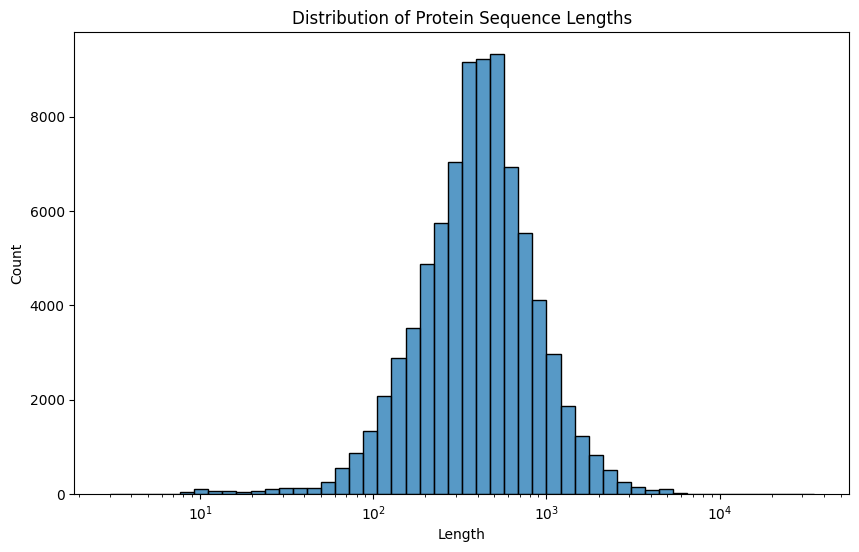

Total unique terms: 26125
Top 10 most frequent terms:
GO:0005515    33713
GO:0005634    13283
GO:0005829    13040
GO:0005886    10150
GO:0005737     9442
GO:0005739     5807
GO:0005654     5065
GO:0016020     3563
GO:0042802     3547
GO:0005576     3241
Name: term, dtype: int64


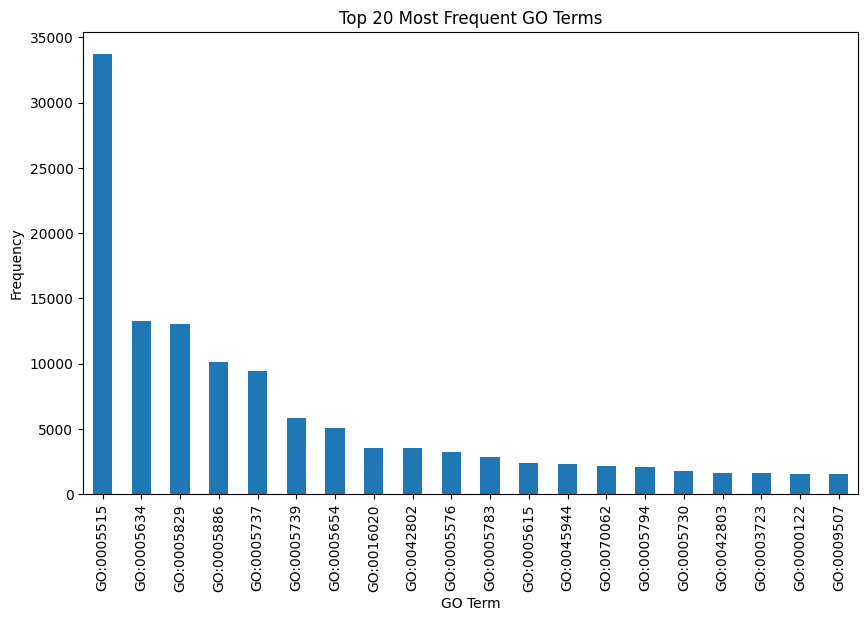

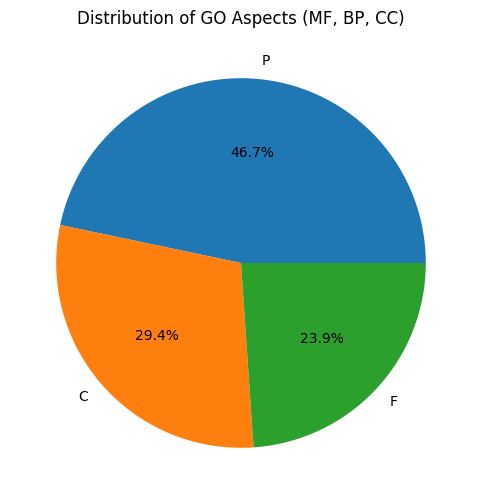

In [7]:
# Sequence Length Distribution
df_seq['Length'] = df_seq['Sequence'].apply(len)
plt.figure(figsize=(10, 6))
sns.histplot(df_seq['Length'], bins=50, log_scale=(True, False))
plt.title("Distribution of Protein Sequence Lengths")
plt.xlabel("Length")
plt.ylabel("Count")
plt.show()

# GO Term Frequency
term_counts = df_terms['term'].value_counts()
print(f"Total unique terms: {len(term_counts)}")
print("Top 10 most frequent terms:")
print(term_counts.head(10))

plt.figure(figsize=(10, 6))
term_counts.head(20).plot(kind='bar')
plt.title("Top 20 Most Frequent GO Terms")
plt.xlabel("GO Term")
plt.ylabel("Frequency")
plt.show()

# Aspect Distribution
aspect_counts = df_terms['aspect'].value_counts()
plt.figure(figsize=(6, 6))
aspect_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title("Distribution of GO Aspects (MF, BP, CC)")
plt.ylabel("")
plt.show()

## 6. Data Preprocessing and Tokenization

Convert amino acid sequences to numerical indices and encode targets.

In [8]:
# Load ESM-2 Tokenizer
# We use a larger version of ESM-2 for better performance: esm2_t33_650M_UR50D
model_checkpoint = "facebook/esm2_t33_650M_UR50D"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

MAX_LEN = 512 # ESM-2 can handle up to 1024, but we limit to 512 for memory

# Select top N terms for classification
NUM_CLASSES = 1500
top_terms = term_counts.head(NUM_CLASSES).index.tolist()
term_to_idx = {term: i for i, term in enumerate(top_terms)}

def encode_labels(protein_id, df_terms, term_to_idx):
    terms = df_terms[df_terms['EntryID'] == protein_id]['term'].values
    label = np.zeros(len(term_to_idx))
    for term in terms:
        if term in term_to_idx:
            label[term_to_idx[term]] = 1
    return label

print(f"Tokenizer loaded: {model_checkpoint}")
print(f"Number of classes: {NUM_CLASSES}")

Tokenizer loaded: facebook/esm2_t33_650M_UR50D
Number of classes: 1500


## 7. Dataset and Dataloader Creation

Create PyTorch Dataset and DataLoaders.

In [9]:
class ProteinDataset(Dataset):
    def __init__(self, df_seq, df_terms, term_to_idx, tokenizer, max_len=MAX_LEN):
        self.df_seq = df_seq
        self.df_terms = df_terms
        self.term_to_idx = term_to_idx
        self.tokenizer = tokenizer
        self.max_len = max_len
        
        # Pre-group terms by protein ID for faster access
        self.grouped_terms = df_terms.groupby('EntryID')['term'].apply(set).to_dict()

    def __len__(self):
        return len(self.df_seq)

    def __getitem__(self, idx):
        row = self.df_seq.iloc[idx]
        protein_id = row['EntryID']
        seq = row['Sequence']
        
        # Tokenize using ESM-2 tokenizer
        encoding = self.tokenizer(
            seq,
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        
        input_ids = encoding['input_ids'].squeeze(0)
        attention_mask = encoding['attention_mask'].squeeze(0)
        
        # Encode Label
        label = np.zeros(len(self.term_to_idx), dtype=np.float32)
        if protein_id in self.grouped_terms:
            terms = self.grouped_terms[protein_id]
            for term in terms:
                if term in self.term_to_idx:
                    label[self.term_to_idx[term]] = 1.0
        
        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'labels': torch.tensor(label, dtype=torch.float32)
        }

# Split Data
from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(df_seq, test_size=0.2, random_state=42)

train_dataset = ProteinDataset(train_df, df_terms, term_to_idx, tokenizer)
val_dataset = ProteinDataset(val_df, df_terms, term_to_idx, tokenizer)

BATCH_SIZE = 2 # Reduced batch size for larger transformer model
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

Training samples: 65923
Validation samples: 16481


## 8. Define Deep Learning Model Architecture

We use a pre-trained ESM-2 model as the backbone and add a classification head.

In [10]:
class ESM2ForProteinFunction(nn.Module):
    def __init__(self, model_checkpoint, num_classes):
        super(ESM2ForProteinFunction, self).__init__()
        self.esm = EsmModel.from_pretrained(model_checkpoint)
        self.fc = nn.Linear(self.esm.config.hidden_size, num_classes)
        self.sigmoid = nn.Sigmoid()

    def forward(self, input_ids, attention_mask):
        outputs = self.esm(input_ids=input_ids, attention_mask=attention_mask)
        # Use the representation of the [CLS] token (first token)
        cls_representation = outputs.last_hidden_state[:, 0, :]
        logits = self.fc(cls_representation)
        return self.sigmoid(logits)

model = ESM2ForProteinFunction(model_checkpoint, NUM_CLASSES)

# Unfreeze ESM layers to allow fine-tuning
# for param in model.esm.parameters():
#     param.requires_grad = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.backends.mps.is_available():
    device = torch.device("mps") # Use Metal Performance Shaders on Mac

model.to(device)
print(f"Model loaded on {device}")

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t33_650M_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t33_650M_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded on cpu


## 9. Model Training Loop

Train the model using Binary Cross Entropy Loss.

In [11]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=5e-5) # Lower learning rate for fine-tuning

EPOCHS = 10 

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
    
    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            
    print(f"Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss/len(train_loader):.4f}, Val Loss: {val_loss/len(val_loader):.4f}")

# Save model
torch.save(model.state_dict(), "protein_esm2.pth")
print("Model saved.")

: 

: 

: 

## 10. Load Test Data and Generate Predictions

Load `testsuperset.fasta` and generate predictions.

In [ ]:
test_fasta_path = os.path.join(TEST_DIR, "testsuperset.fasta")

test_ids = []
test_sequences = []
for record in SeqIO.parse(test_fasta_path, "fasta"):
    test_ids.append(record.id)
    test_sequences.append(str(record.seq))

# Create Dataset for test (reuse ProteinDataset logic but without labels)
class TestProteinDataset(Dataset):
    def __init__(self, sequences, tokenizer, max_len=MAX_LEN):
        self.sequences = sequences
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq = self.sequences[idx]
        encoding = self.tokenizer(
            seq,
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0)
        }

test_dataset = TestProteinDataset(test_sequences, tokenizer)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Predict
model.eval()
all_probs = []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        outputs = model(input_ids, attention_mask)
        all_probs.append(outputs.cpu().numpy())

all_probs = np.concatenate(all_probs)
print(f"Predictions shape: {all_probs.shape}")

Predictions shape: (224309, 500)


## 11. Post-processing: Score Propagation

Propagate scores to parent terms using the GO graph.

In [ ]:
# Score Propagation
# We use the GO graph to propagate scores from children to parents.
# Rule: P(Parent) >= P(Child)

# Precompute ancestors for each term in our subset
# Assuming edges in go_graph are Child -> Parent (standard for obonet)
ancestor_map = {}
print("Precomputing ancestors...")
for i, term in enumerate(top_terms):
    if term in go_graph:
        try:
            # nx.ancestors returns all nodes reachable from term (parents, grandparents, etc.)
            ancestors = nx.ancestors(go_graph, term)
            # Filter to only those terms we are predicting
            ancestor_indices = [term_to_idx[a] for a in ancestors if a in term_to_idx]
            if ancestor_indices:
                ancestor_map[i] = ancestor_indices
        except Exception as e:
            pass

print(f"Ancestors precomputed for {len(ancestor_map)} terms.")

def propagate_scores(probs, ancestor_map):
    # probs: (num_samples, num_classes)
    # We want to update parent scores based on children.
    # Since ancestor_map contains all ancestors (transitive), we can just update
    # all ancestors for each term.
    
    new_probs = probs.copy()
    
    # Iterate through each term. 
    # Note: This loop can be slow if num_classes is huge, but for 1500 it's fine.
    for i in range(probs.shape[1]):
        if i in ancestor_map:
            parents = ancestor_map[i]
            # Update all parents with the score of term i
            # new_probs[:, parents] = max(new_probs[:, parents], new_probs[:, i])
            # We use numpy broadcasting
            child_scores = new_probs[:, i:i+1] # Shape (N, 1)
            new_probs[:, parents] = np.maximum(new_probs[:, parents], child_scores)
            
    return new_probs

print("Propagating scores...")
propagated_probs = propagate_scores(all_probs, ancestor_map)
print("Score propagation complete.")

## 12. Create Submission File

Format predictions into TSV.

In [ ]:
submission_data = []
idx_to_term = {v: k for k, v in term_to_idx.items()}

for i, protein_id in enumerate(test_ids):
    probs = propagated_probs[i]
    # Get top predictions or all non-zero
    # Limit to 1500 as per rules
    top_indices = np.argsort(probs)[::-1][:1500]
    
    for idx in top_indices:
        score = probs[idx]
        if score > 0.01: # Threshold to reduce file size
            term = idx_to_term[idx]
            submission_data.append([protein_id, term, f"{score:.3f}"])

df_submission = pd.DataFrame(submission_data, columns=['Protein Id', 'GO Term Id', 'Prediction'])
df_submission.to_csv("submission.tsv", sep='\t', index=False, header=False)
print("Submission file created: submission.tsv")
print(df_submission.head())

Submission file created: submission.tsv
   Protein Id  GO Term Id Prediction
0  A0A0C5B5G6  GO:0005576      0.320
1  A0A0C5B5G6  GO:0005515      0.197
2  A0A0C5B5G6  GO:0005739      0.146
3  A0A0C5B5G6  GO:0005829      0.117
4  A0A0C5B5G6  GO:0005634      0.104
